In [1]:
import sys
import os
from pathlib import Path
from dotenv import load_dotenv
import importlib
import pandas as pd
import numpy as np
import importlib

sys.path.append(os.path.abspath(".."))

import src.utils.optuna_visualizer as opv
import src.utils.telegram as te
import src.utils.hill_climbing as hc

In [2]:
# Load data
# MLP
oof_single_31 = np.load("../artifacts/preds/l1/oof_single_31.npy")
oof_single_45 = np.load("../artifacts/preds/l1/oof_single_45.npy")

# XGB
oof_single_38 = np.load("../artifacts/preds/l1/oof_single_38.npy")

# CB
oof_single_28 = np.load("../artifacts/preds/l1/oof_single_28.npy")

# LGBM
oof_single_40 = np.load("../artifacts/preds/l1/oof_single_40.npy")

oof_array = np.vstack([oof_single_31, oof_single_45, oof_single_38, oof_single_28, oof_single_40]).T
y_true = pd.read_parquet("../artifacts/features/base/tr_df1.parquet")["target"].to_numpy()

0 We begin with best single model AUC 0.97604from 0
New best score: 0.9760414808101056
adding: 1
with weight: 0.370

=> We reached tolerance 1e-05
   weight  model    score
0    0.63      0  0.97604
1    0.37      1  0.97608


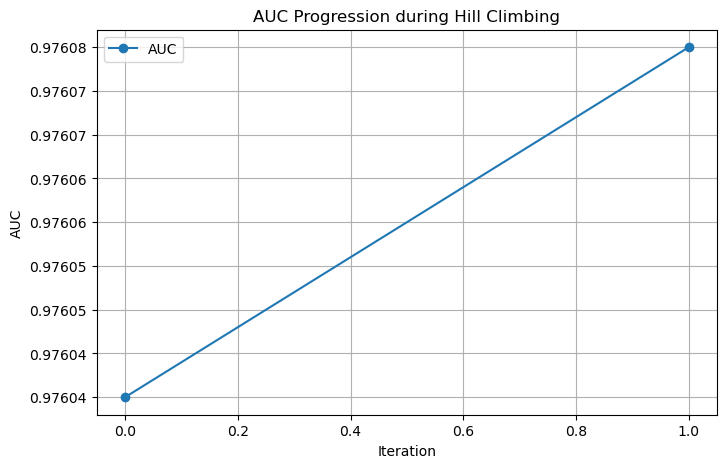

In [3]:
importlib.reload(hc)
hc.hill_climbing_auc(oof_array, y_true)